# Tutorial 10 -- Time Rabi

Sweep the pulse duration at fixed amplitude, fit the oscillation period, and estimate the `pi` and `pi/2` durations.

**Prerequisites.** Tutorials 04 and 09 are recommended first.


## 1. Goal

We will keep the pulse amplitude fixed, vary the pulse duration, and fit the resulting oscillation to recover the Rabi rate.


## 2. Physical Background

With a fixed resonant square-pulse amplitude `Omega`, the two-level result is `P_e(t) = sin^2(Omega t)`. The time-Rabi experiment therefore measures the oscillation period in duration space and infers `t_pi = pi / (2 Omega)`.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
omega_rabi = 2.0 * np.pi * 12.0e6
durations_ns = np.linspace(0.0, 120.0, 49)
dt = 2.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=1,
    n_tr=2,
)
frame = FrameSpec(omega_q_frame=model.omega_q)
spectrum_levels = min(6, int(np.prod(model.subsystem_dims)))


## 6. Pulse / Sequence Construction


In [4]:
durations_s = durations_ns * ns
responses = []
for duration_s in durations_s:
    pulse = Pulse("q", 0.0, float(max(duration_s, dt)), square_envelope, amp=omega_rabi, carrier=0.0, label="time_rabi")
    compiled = SequenceCompiler(dt=dt).compile([pulse], t_end=float(max(duration_s, dt)) + dt)
    result = simulate_sequence(
        model,
        compiled,
        model.basis_state(0, 0),
        {"q": "qubit"},
        config=SimulationConfig(frame=frame, max_step=dt),
    )
    responses.append(final_expectation(result, "P_e"))
responses = np.asarray(responses, dtype=float)


## 7. Running the Simulation


In [5]:
theory_responses = resonant_drive_excited_population(omega_rabi, np.maximum(durations_s, dt))
fit = fit_rabi_vs_duration(durations_s, responses)
print(f"Estimated pi time = {fit.parameters['pi_time_s'] / ns:.3f} ns")
print(f"Estimated pi/2 time = {fit.parameters['pi_over_two_time_s'] / ns:.3f} ns")
print(f"RMS deviation from sin^2(Omega t): {np.sqrt(np.mean((responses - theory_responses) ** 2)):.3e}")


Estimated pi time = 40.716 ns
Estimated pi/2 time = 20.358 ns
RMS deviation from sin^2(Omega t): 4.127e-02


## 8. Visualizing the Results


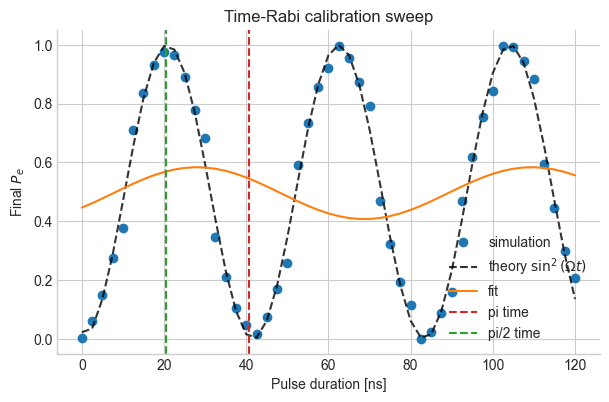

In [6]:
fig, ax = plt.subplots()
ax.plot(durations_ns, responses, "o", label="simulation")
ax.plot(durations_ns, theory_responses, "--", color="black", alpha=0.8, label=r"theory $\sin^2(\Omega t)$")
ax.plot(durations_ns, fit.model_y, "-", label="fit")
ax.axvline(fit.parameters["pi_time_s"] / ns, color="tab:red", linestyle="--", label="pi time")
ax.axvline(fit.parameters["pi_over_two_time_s"] / ns, color="tab:green", linestyle="--", label="pi/2 time")
ax.set_xlabel("Pulse duration [ns]")
ax.set_ylabel(r"Final $P_e$")
ax.set_title("Time-Rabi calibration sweep")
ax.legend()
plt.show()


## 9. Physical Interpretation

Time-Rabi and power-Rabi are two views of the same control scale. In practice one is often easier to scan than the other depending on how the hardware exposes pulse settings.


## 10. Exercises / Next Steps

- Repeat the fit with a different fixed amplitude and verify that the `pi` time rescales as expected.
- Change the frame or add a detuning to see how off-resonant driving distorts the simple sinusoidal picture.
- Continue to Tutorial 25 for a compact workflow that combines spectroscopy and Rabi information.
